In [1]:
import numpy as np
import matplotlib.pyplot as plt
from picca import constants
import h5py
from scipy import constants as scipy_constants

import sys
import os
sys.path.append(os.path.abspath(".."))
from w1_w2 import wave_to_fft_profile, resample_to_logk

This file can be used with two purposes:

A) Recreating Fig.5 in Tan25 - Computing w2 and Fhcd:
   For that, z = 2.23, lognhi ranges from 17.3 to 20.3 (to compare with the grey line) and rho_hcd = 0.00158 Ä^-1.

B) Recreating Fig. B1 in MW11 - After computing w2 and Fhcd we will compute P1d and P3d in the 'powers' notebook
   For that, z = 2.5 and rho_hcd = 0.0018/hubble. I'm not sure on the lognhi ranges used in MW11 (not mentioned), but I'll keep the 17.3 to 20.3 range (¿?)

In [2]:
# MW21 cosmology values
hubble, z = 0.71, 2.5
omegab, omegam = 0.046, 0.27
omegal = 1 - omegam
ns = 0.96

# MW11 

## cddf 

In [3]:
def f_Nhi(colden, k, b):
    y = k*(colden**b)
    return y

The parameters b1 and b2 are given in the paper. k1 and k2 are determinated so that:
- the integration of f_nhi from logNhi=19 to logNhi=20.3 (cm^-2) is 0.1
- f_Nhi(k1, b1) = f_Nhi(k2, b2) at logNhi = 20.3

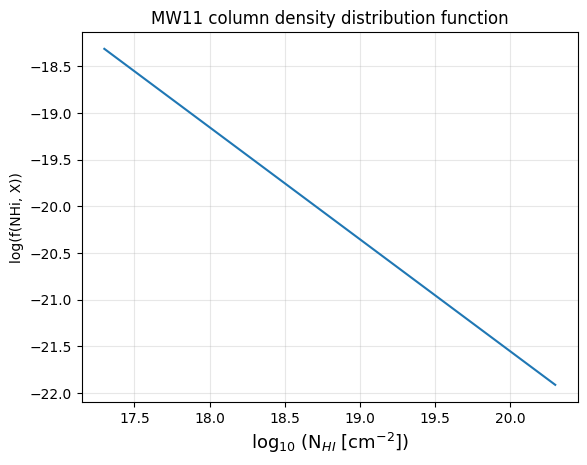

In [4]:
k1, b1 = 280.14, -1.2
k2, b2 = 4.24e14, -1.8

NHirange = np.linspace(17.3, 20.3)
colden1, colden2 = NHirange[NHirange < 20.3], NHirange[NHirange >= 20.3]
fnhi_mw11 = np.concatenate([f_Nhi(10**colden1, k1, b1), f_Nhi(10**colden2, k2, b2)])

plt.plot(NHirange, np.log10(fnhi_mw11))
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel('log(f(NHi, X))')
plt.title('MW11 column density distribution function')
plt.grid(alpha=0.3);

With this f_Nhi we can define the column density distribution function as:

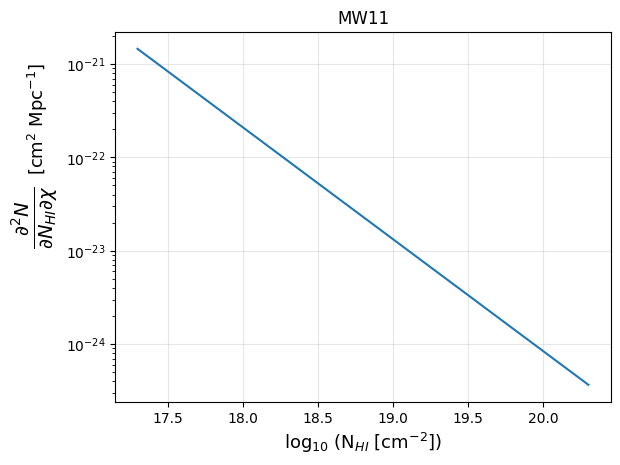

In [5]:
c_kms = constants.speed_light*1e-3  # kms^-1
#cddf_mw11 = fnhi_mw11*100*hubble*((1+z)**2)/c_kms  
H_z = 100*hubble*np.sqrt(omegal + omegam*((1+z)**3))  # EdS approx (as in MW11)
cddf_mw11 = fnhi_mw11*H_z*np.sqrt((1+z)/omegam)/c_kms

plt.plot(NHirange, cddf_mw11)
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial^2 N}{\partial N_{HI}\partial \chi}$', fontsize=20)
plt.text(-0.18, 0.63, r'[cm$^2$ Mpc$^{-1}$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.yscale('log')
plt.title('MW11')
plt.grid(alpha=0.3);

## w2

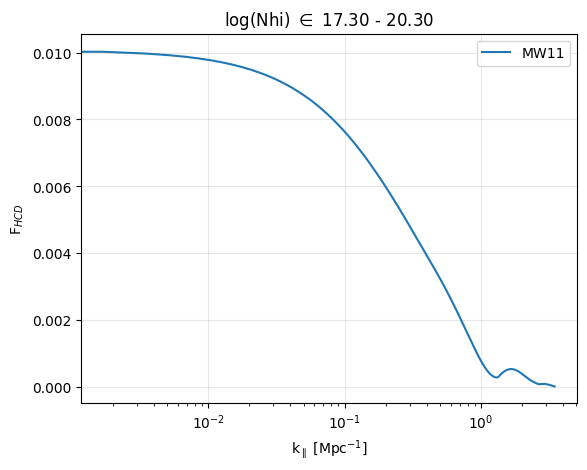

In [27]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log
Fmean_hcd = 0.9779275149014024

# MW11
w2_int, w1_int = [], []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam, hubble=hubble)
    w2_int.append(cddf_mw11[i]*d*np.log(10)*(10**nhi_value))
    w1_int.append(cddf_mw11[i]*(d**2)*np.log(10)*(10**nhi_value))  # We will need this for later

w2_int, w1_int = np.array(w2_int), np.array(w1_int)
w1_MW11 = np.trapezoid(w1_int, NHirange, axis=0)
w2_MW11 = np.trapezoid(w2_int, NHirange, axis=0)
w2_MW11 /= Fmean_hcd  # Correction suggested in Tan25
w1_MW11 /= Fmean_hcd  # Correction suggested in Tan25

plt.plot(k_w1w2, w2_MW11, label='MW11')
plt.ylabel(r'F$_{HCD}$')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

# Vega-pyigm-Tan

This cddf is normalized so we will compute w1 and w2 as in Tan25: ccdf_vega = fn_vega*rho_hcd

## cddf

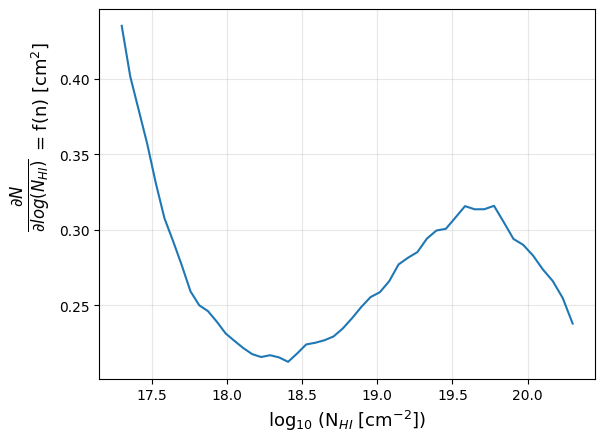

In [28]:
data_vega = np.loadtxt('/Users/lflores/Documents/Research/phd/hcd/work_in_progress/Comparisons/fn_nomasking.txt')
fn_vega = np.interp(NHirange, data_vega[1], data_vega[0])

plt.plot(NHirange, fn_vega)
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial log(N_{HI})}$', fontsize=17)
plt.text(-0.14, 0.63, r'= f(n) [cm$^2$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.grid(alpha=0.3)

In [29]:
import lace.cosmo.camb_cosmo as camb_cosmo
from lace.cosmo.camb_cosmo import dAA_dMpc as dAA_dMpc_func
cosmocamb = camb_cosmo.get_cosmology(H0=100*hubble, omch2=omegam*(hubble**2), ombh2=omegab*(hubble**2), ns=ns)
#rho_hcd = 0.00158*dAA_dMpc_func(cosmo=cosmocamb, z=z, lambda_AA=1215.67) # Mpc^-1 for z = 2.29 (Tan25) 
rho_hcd = 0.0018/hubble  # Mpc^-1 for z = 2.5 (MW11)

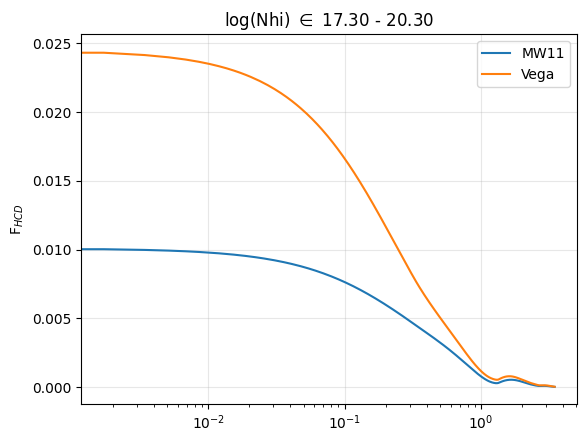

In [30]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log

# Vega
w2_int = []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam, hubble=hubble)
    w2_int.append(fn_vega[i]*d)

w2_int = np.array(w2_int)
w2_vega = rho_hcd*np.trapezoid(w2_int, NHirange, axis=0)

plt.plot(k_w1w2, w2_MW11, label='MW11')
plt.plot(k_w1w2, w2_vega, label='Vega')
plt.ylabel(r'F$_{HCD}$')
plt.legend()
plt.xscale('log')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

# ASTRID

In [12]:
data_on = '/Users/lflores/Documents/Research/phd/hcd/w1_w2/data/spectra_ASTRID_z2.5_500x500x2500.hdf5'  # With self-shielding

with h5py.File(data_on, 'r') as f:
    print('Keys:', f.keys())
    header_on = f['Header']
    print('------ Header ------')
    for attr in header_on.attrs:
            print(f"{attr} : {header_on.attrs[attr]}")
    print('------ Data ------')
    colden = f['colden/H/1'][:]
    print('colden shape:', colden.shape)  

Keys: <KeysViewHDF5 ['Header', 'colden', 'spectra', 'tau']>
------ Header ------
Hz : 252.87249366801257
box : 250000.0
discarded : 0
hubble : 0.6774
nbins : 2500
npart : [165988309584 166375000000            0            0  10297622146
     11325619]
omegab : 0.0486
omegal : 0.6911
omegam : 0.3089
redshift : 2.499999947500001
------ Data ------
colden shape: (250000, 2500)


In [13]:
print('----- Useful information -----')
Lbox = 250  # Mpc/h
print('box size:', Lbox, 'Mpc/h')

# Number of skewers per side
Nsk = int(np.sqrt(colden.shape[0]))  # colden.on_shape[0] gives the size of the axis
print(Nsk,'skewers per side')

# Number of pixels per skewer
Np = colden.shape[1] # colden.on_shape[1] gives the size of the columns
print(Np, 'pixels per skewer')

# Pixel width 
Pw = Lbox/Np  # Mpc/h 
print(Pw, 'Mpc/h pixel width')
# We are dividing the total box width in comoving units by the number of pixels in each skewer

# Minimum separation between skewers
Ssk = Lbox/Nsk  # Mpc/h 
print(Ssk, 'Mpc/h skewer separation')
# We are dividing the total box width in comoving units by the number of skewers per side

----- Useful information -----
box size: 250 Mpc/h
500 skewers per side
2500 pixels per skewer
0.1 Mpc/h pixel width
0.5 Mpc/h skewer separation


In [14]:
colden_log = np.log10(colden)
counts, _ = np.histogram(colden_log, bins=NHirange)
mid_nhi = (NHirange[:-1] + (NHirange[1] - NHirange[0])/2)

/var/folders/4r/vx1gr4gd4p99y59swb8x2lzr0000gn/T/ipykernel_73192/2581987579.py:1: RuntimeWarning: divide by zero encountered in log10
  colden_log = np.log10(colden)


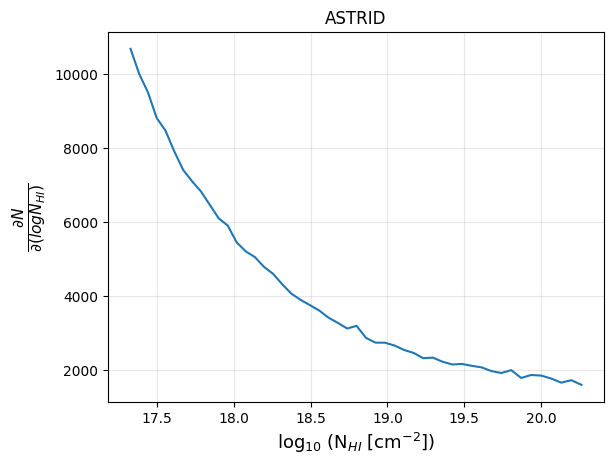

In [15]:
plt.plot(mid_nhi, counts)
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial (logN_{HI})}$',  fontsize=16)
plt.title('ASTRID')
plt.grid(alpha=0.3);

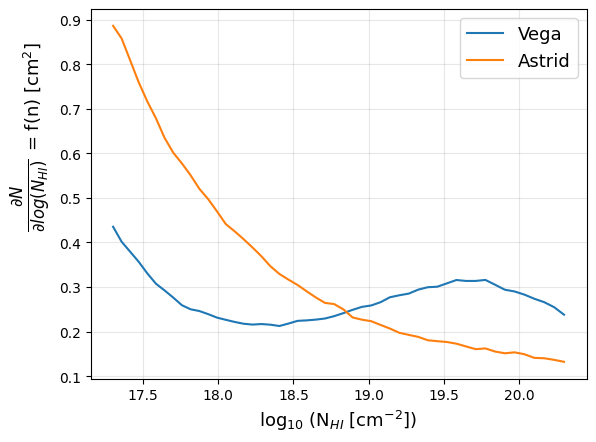

In [31]:
fn_astrid = np.interp(NHirange, mid_nhi, counts)
fn_astrid /= np.trapezoid(fn_astrid, NHirange)

plt.plot(NHirange, fn_vega, label='Vega')
plt.plot(NHirange, fn_astrid, label='Astrid')
plt.xlabel(r'log$_{10}$ (N$_{HI}$ [cm$^{-2}])$', fontsize=13)
plt.ylabel(r'$\frac{\partial N}{\partial log(N_{HI})}$', fontsize=17)
plt.text(-0.14, 0.63, r'= f(n) [cm$^2$]', transform=plt.gca().transAxes, fontsize=13, rotation=90)
plt.grid(alpha=0.3)
plt.legend(fontsize=13);

In [32]:
import lace.cosmo.camb_cosmo as camb_cosmo
from lace.cosmo.camb_cosmo import dAA_dMpc as dAA_dMpc_func
cosmocamb = camb_cosmo.get_cosmology(H0=100*hubble, omch2=omegam*(hubble**2), ombh2=omegab*(hubble**2), ns=ns)
#rho_hcd = 0.00158*dAA_dMpc_func(cosmo=cosmocamb, z=z, lambda_AA=1215.67) # Mpc^-1 Used for For Fig.5 in Tan25
rho_hcd = 0.0018/hubble  # Used for MW11

wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log

# Astrid
w2_int = []
for i, nhi_value in enumerate(NHirange):
    k_w1w2, d, Deltax = wave_to_fft_profile(wave, z, nhi_value, omegam=omegam, hubble=hubble)
    w2_int.append(fn_astrid[i]*d)

w2_int = np.array(w2_int)

w2_astrid = rho_hcd*np.trapezoid(w2_int, NHirange, axis=0)

We can resample to logarithmic binning of k_paralel taking into account Nyquist frequency

In [33]:
print(r'Min value of k_los is', k_w1w2.min(), 'h/Mpc')
print(r'Max value of k_los is', k_w1w2.max(), 'h/Mpc')
print(r'But Nyquist frecuency is', np.pi/(Deltax), 'h/Mpc')
k_los, w2_MW11 = resample_to_logk(k_w1w2, w2_MW11, k_max=np.pi/(Deltax*2))  # Resample to logarithmic binning
k_los, w1_MW11 = resample_to_logk(k_w1w2, w1_MW11, k_max=np.pi/(Deltax*2))  
k_los, w2_vega = resample_to_logk(k_w1w2, w2_vega, k_max=np.pi/(Deltax*2))
k_los, w2_astrid = resample_to_logk(k_w1w2, w2_astrid, k_max=np.pi/(Deltax*2))
print('After truncation to avoid Nyquist frecuency')
print(r'Min value of k_los is', k_los.min(), 'Mpc^-1')
print(r'Max value of k_los is', k_los.max(), 'Mpc^-1')

Min value of k_los is 0.0 h/Mpc
Max value of k_los is 3.487529273466229 h/Mpc
But Nyquist frecuency is 3.4875292734662287 h/Mpc
After truncation to avoid Nyquist frecuency
Min value of k_los is 0.0017028951530596826 Mpc^-1
Max value of k_los is 1.7437646367331143 Mpc^-1


In [34]:
# LEt's export this into a txt file:
data = np.column_stack((k_los, w2_vega, w2_astrid, w2_MW11, w1_MW11))
np.savetxt('w2_functions.txt', data, fmt='%.6e', header='k_los, Vega, Astrid (with Tan25 procedure, MW11, w2 from MW11')

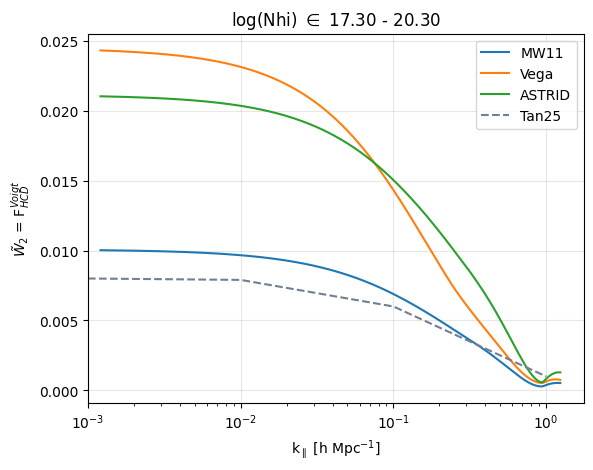

In [37]:
plt.plot(k_los*hubble, w2_MW11, label='MW11')
plt.plot(k_los*hubble, w2_vega, label='Vega')
plt.plot(k_los*hubble, w2_astrid, label='ASTRID')
plt.plot([1e-3, 1e-2, 1e-1, 1], [0.008, 0.0079, 0.006, 0.001], color='slategrey', linestyle='--', label='Tan25')  # lognHI = 17.3 - 20.3
#plt.plot([1e-3, 1e-2, 1e-1, 1], [0.018, 0.017, 0.009, 0.001], color='slategrey', linestyle='--', label='Tan25')  # lognHI = 17.3 - 22.5
plt.legend()
plt.xscale('log')
plt.xlim(left=1e-3)
plt.grid(alpha=0.3)
plt.xlabel(r'k$_\parallel$ [h Mpc$^{-1}$]')
plt.ylabel(r'$\tilde{W}_2$ = F$_{HCD}^{Voigt}$')
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

# Exponential model

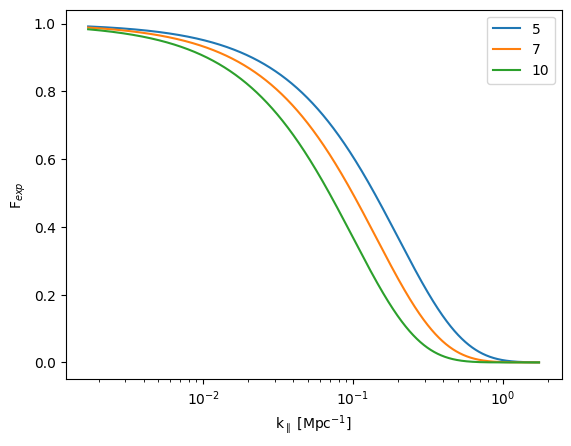

In [100]:
L_hcd = 7  # Mpc
F_exp5 = np.exp(-5*k_los)
F_exp7 = np.exp(-L_hcd*k_los)
F_exp10 = np.exp(-10*k_los)

plt.plot(k_los, F_exp5, label='5')
plt.plot(k_los, F_exp7, label='7')
plt.plot(k_los, F_exp10, label='10')
plt.ylabel(r'F$_{exp}$')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]');

Let's make a comparison of the b'lya parameter

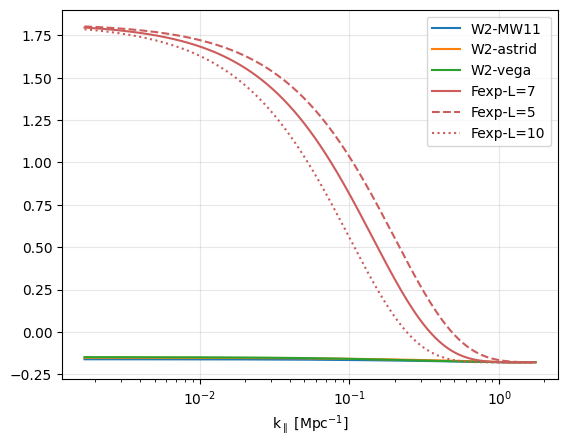

In [101]:
bias_lya, bias_hcd = -0.18, 2
plt.plot(k_los, (bias_lya + bias_hcd*w2_MW11), label='W2-MW11')
plt.plot(k_los, (bias_lya + bias_hcd*w2_astrid), label='W2-astrid')
plt.plot(k_los, (bias_lya + bias_hcd*w2_vega), label='W2-vega')
plt.plot(k_los, (bias_lya + bias_hcd*F_exp7), color='indianred', label='Fexp-L=7')
plt.plot(k_los, (bias_lya + bias_hcd*F_exp5), color='indianred', linestyle='--', label='Fexp-L=5')
plt.plot(k_los, (bias_lya + bias_hcd*F_exp10), color='indianred', linestyle=':', label='Fexp-L=10')
plt.xscale('log')
plt.legend()
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.grid(alpha=0.3);